# Testing Data Configs
This notebook tests different combinations of dataset config parameters (background subtraction, normalisation, resizing) to find the optimal config for initial Touch-Ex dataset model building. These parameters may well be fine-tuned further into the development process, but this gives us a good starting point.

We will use the 'object' label for our classification models.

**Notes**: 
- This notebook reflects an early implementation of the data and training pipeline. Later additions—such as configurable learning-rate warmup and cosine decay—may not be represented here.
- Due to issues with ipywidgets in Visual Studio Code, the progress bars show 0% instead of the correct 100%.

In [3]:
# Allow imports from the parent directory
import sys
import os

module_path = os.path.abspath(os.path.join(".."))
sys.path.append(module_path)

In [4]:
# Imports
import torch
import pandas as pd
import matplotlib.pyplot as plt
from data.builder import get_dataloaders
from models.baseline import BaselineCNNModel
from models.pretrained import PretrainedModel
from models.train_eval import train_classifier, eval_classifier
from models.torch_functions import get_device

In [5]:
# Setup cuda
device = get_device()
device

device(type='cuda')

In [6]:
# Set random seed for reproducibility
torch.manual_seed(123)
torch.cuda.manual_seed_all(123)

## Testing Image Settings
We will start by testing the best combination of the following settings:

**Resize method:** Pad and then resize tactile images to 224x224 **OR** centre crop to 224x224.

**Normalisation:** Normalise tactile images using the train split mean and std **OR** don't normalise.

**Background subtraction:** Subtract the baseline.jpg image (DIGIT output when no contact with an object is made) **OR** no background subtraction.

All combinations of these gives 8 different configurations.

#### Load Data

In [5]:
# Define the data configuration
data_config = {
    "random_state": 167,  # Random seed for reproducibility
    "split_size": 0.2,  # Proportion of the dataset to include in the val/test splits
    "stratify_label": "object",  # Label to use for stratified splitting of the dataset
    "filtered_force_level": None,  # Filter to include only samples with this force level
    "filtered_motion": None,  # Filter to include only samples with this motion
    "transform_name": "pad_224",  # Transformation to apply to the images
    "bg_path": None,  # Path to the background images for background subtraction
    "norm_type": None,  # Normalisation type to apply to the images
    "norm_cache_path": "../configs/norm_cache.json",  # Path to the normalisation cache file
    "batch_size": 32,  # Batch size for the dataloaders
    "num_workers": 0,  # Number of workers for the dataloaders
    "shuffle_map": {
        "train": True,
        "val": False,
        "test": False,
    },  # Whether to shuffle the data in the dataloaders for each split
}

In [6]:
# Create a list of data configs for each fold
# Start with default config and modify the fold-specific parameters for each fold
data_configs = [data_config.copy() for _ in range(8)]

In [7]:
# Set the path name for the baseline background image
BG_PATH = "../data/baseline.jpg"

In [8]:
# Define the different combinations of data config parameters to test
changes = [
    {"transform_name": "pad_224", "norm_type": None, "bg_path": None},
    {"transform_name": "pad_224", "norm_type": None, "bg_path": BG_PATH},
    {"transform_name": "pad_224", "norm_type": "dataset", "bg_path": None},
    {"transform_name": "pad_224", "norm_type": "dataset", "bg_path": BG_PATH},
    {"transform_name": "center_crop_224", "norm_type": None, "bg_path": None},
    {"transform_name": "center_crop_224", "norm_type": None, "bg_path": BG_PATH},
    {"transform_name": "center_crop_224", "norm_type": "dataset", "bg_path": None},
    {"transform_name": "center_crop_224", "norm_type": "dataset", "bg_path": BG_PATH},
]

In [10]:
# Define the titles for each data config combination
titles = [
    "pad_224_no_norm_no_bg",
    "pad_224_no_norm_bg",
    "pad_224_dataset_norm_no_bg",
    "pad_224_dataset_norm_bg",
    "center_crop_224_no_norm_no_bg",
    "center_crop_224_no_norm_bg",
    "center_crop_224_dataset_norm_no_bg",
    "center_crop_224_dataset_norm_bg",
]

In [11]:
# Update the data configs with the different combinations of parameters
for i in range(len(data_configs)):
    data_configs[i].update(changes[i])

In [12]:
# Get (dataloaders, label_lists) tuples for each fold using the different data configs
data = [get_dataloaders(cfg) for cfg in data_configs]

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
No

In [13]:
# Split into dataloaders and class-label lists for easier access
dataloaders = [item[0] for item in data]
label_lists = [item[1] for item in data]

In [14]:
# Get the training object labels from the first training class list (same for all)
train_object_labels = label_lists[0]["train"]["object"]
train_object_labels

['football',
 'hammer',
 'mug',
 'plastic_bottle',
 'scissors',
 'sponge_scourer',
 'tea_towel',
 'tennis_ball',
 'tin_beans',
 'toilet_roll',
 'toothbrush',
 'tube_pringles',
 'tv_remote',
 'wooden_spoon']

In [15]:
# Confirm number of classes
num_train_classes = len(train_object_labels)
num_train_classes

14

#### Training

In [16]:
# Define a default model training configuration
train_config = {
    "optimizer": "adam",
    "learning_rate": 0.002,
    "momentum": 0.9,
    "weight_decay": 0,
    "num_epochs": 3,
    "checkpoint_dir": "../checkpoints/test_data_configs",
    "model_title": "test_data_configs",
}

In [17]:
# Create a list of training configs for each fold
train_configs = [train_config.copy() for _ in range(8)]

In [18]:
# Update the training configs with the different titles for each fold
for i in range(len(train_configs)):
    train_configs[i]["model_title"] = titles[i]

In [19]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = BaselineCNNModel(num_classes=num_train_classes)
    # Train the model and save the history
    model, history = train_classifier(
        model=model,
        device=device,
        train_loader=dataloaders[i]["train"],
        val_loader=dataloaders[i]["val"],
        target_label="object",
        train_config=train_configs[i],
    )
    models.append(model)
    histories.append(history)
    print("-----")

Starting training of pad_224_no_norm_no_bg on device: cuda


Epoch 1/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 1/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 1/3 - Train Loss: 2.6416, Train Acc: 6.98%, Val Loss: 2.6395, Val Acc: 6.93%


Epoch 2/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

...

Epoch 2/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 2/3 - Train Loss: 0.0805, Train Acc: 97.62%, Val Loss: 1.6280, Val Acc: 75.39%


Epoch 3/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 3/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 3/3 - Train Loss: 0.0582, Train Acc: 98.34%, Val Loss: 1.9669, Val Acc: 79.75%
Loaded best model checkpoint from epoch 3.
-----


In [20]:
# Convert histories to Pandas DataFrame
# Columns should start from 1 instead of 0 to match epoch numbers
histories_df = pd.DataFrame(
    histories, index=titles, columns=[f"epoch_{i + 1}" for i in range(len(histories[0]))]
)
# Save dataframe to parquet file
histories_df.to_parquet("../results/test_data_configs/histories.parquet", index=True)

In [22]:
histories_df

,epoch_1,epoch_2,epoch_3
pad_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 2.641563420574909, ...","{'epoch': 2, 'train_loss': 2.6393268900993365,...","{'epoch': 3, 'train_loss': 2.6394059688809137,..."
pad_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.27925445102817964...","{'epoch': 2, 'train_loss': 0.04200415647448841...","{'epoch': 3, 'train_loss': 0.03776474813109814..."
pad_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.9502670537092572,...","{'epoch': 2, 'train_loss': 0.2898812425328068,...","{'epoch': 3, 'train_loss': 0.1968833804250705,..."
pad_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.2740782472628714,...","{'epoch': 2, 'train_loss': 0.06355296304495833...","{'epoch': 3, 'train_loss': 0.04537091961572582..."
center_crop_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 2.6404931113059815,...","{'epoch': 2, 'train_loss': 2.639390462287956, ...","{'epoch': 3, 'train_loss': 2.6393889878468917,..."
center_crop_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.4558429191352429,...","{'epoch': 2, 'train_loss': 0.06169794686092899...","{'epoch': 3, 'train_loss': 0.04458551289175335..."
center_crop_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.9072614283569889,...","{'epoch': 2, 'train_loss': 0.21668808982595728...","{'epoch': 3, 'train_loss': 0.14159785198720756..."
center_crop_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.3754415648151867,...","{'epoch': 2, 'train_loss': 0.08054777551485323...","{'epoch': 3, 'train_loss': 0.05817633167490868..."


#### Evaluation

In [23]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    model = models[i]
    result = eval_classifier(
        model=model,
        model_title=titles[i],
        device=device,
        test_loader=dataloaders[i]["test"],
        target_label="object",
    )
    results.append(result)
    print("-----")

Starting test evaluation of pad_224_no_norm_no_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 2.6399, test Accuracy: 6.93%
test Weighted F1 Average: 0.0090
-----
Starting test evaluation of pad_224_no_norm_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 1.2251, test Accuracy: 82.70%
test Weighted F1 Average: 0.8205
-----
Starting test evaluation of pad_224_dataset_norm_no_bg on device: cuda


...

test Loss: 1.2726, test Accuracy: 79.89%
test Weighted F1 Average: 0.7968
-----
Starting test evaluation of center_crop_224_dataset_norm_no_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 2.9484, test Accuracy: 66.54%
test Weighted F1 Average: 0.6581
-----
Starting test evaluation of center_crop_224_dataset_norm_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 1.6501, test Accuracy: 81.06%
test Weighted F1 Average: 0.8046
-----


In [24]:
# Convert test results to Pandas DataFrame
results_df = pd.DataFrame(results, index=titles)
# Save dataframe to parquet file
results_df.to_parquet("../results/test_data_configs/results.parquet", index=True)

In [25]:
results_df

,test_loss,test_acc,weighted_f1_avg,y_true,y_expected,y_pred
pad_224_no_norm_no_bg,2.639950,6.930693,0.008984,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ..."
pad_224_no_norm_bg,1.225135,82.698020,0.820463,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_dataset_norm_no_bg,1.222032,78.094059,0.775161,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 9, 0, 0, 9, 0, 0, 9, 0, 0, 0, 9, 0, ..."
pad_224_dataset_norm_bg,1.032535,81.905941,0.810214,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_no_norm_no_bg,2.639670,6.930693,0.008984,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 1..."
center_crop_224_no_norm_bg,1.272574,79.892739,0.796773,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_dataset_norm_no_bg,2.948411,66.542904,0.658064,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 6, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 2, ..."
center_crop_224_dataset_norm_bg,1.650097,81.056106,0.804634,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [26]:
def plot_metrics(df, target_col, title):
    # Create a bar chart comparing the target metric for each data config
    df[[target_col]].plot(kind="bar", figsize=(12, 6))
    # Show titles with 'no_bg' in a different color
    for i, bar in enumerate(plt.gca().patches):
        if "no_bg" in titles[i]:
            bar.set_color("orange")
    # Configure, save and show the plot
    plt.title(f"{title} (orange bars indicate no_bg config)")
    plt.xlabel("Data Configuration")
    plt.ylabel(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend().set_visible(False)  # Hide legend
    plt.tight_layout()
    plt.savefig(f"../results/test_data_configs/plots/{target_col}.png")
    plt.show()

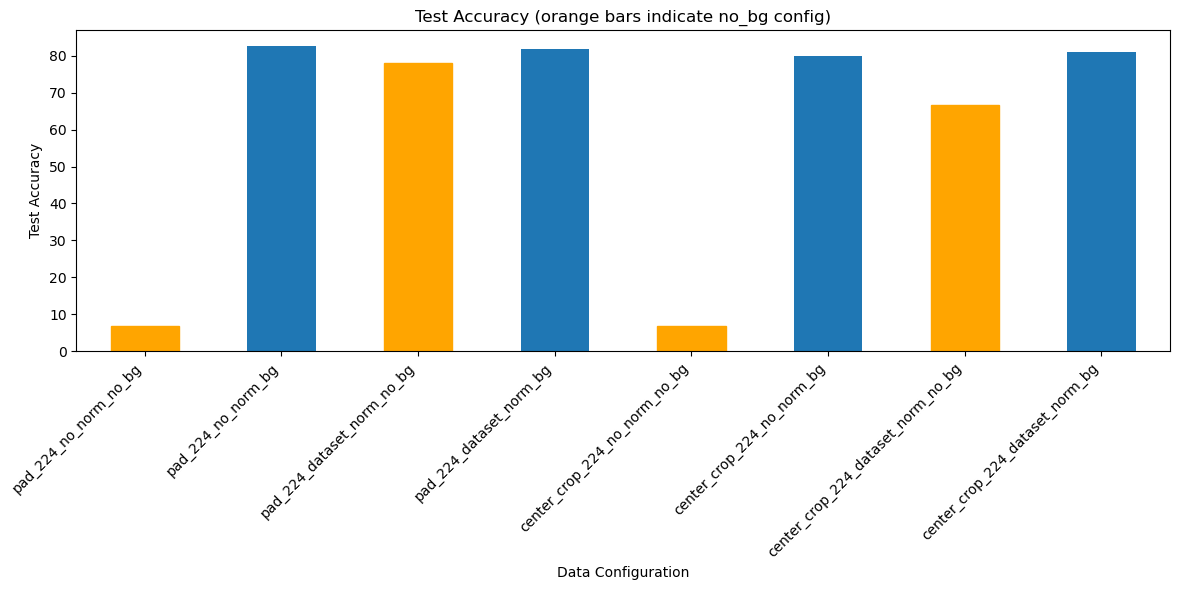

In [27]:
# Bar chart comparing the test accuracy for each fold
plot_metrics(results_df, "test_acc", "Test Accuracy")

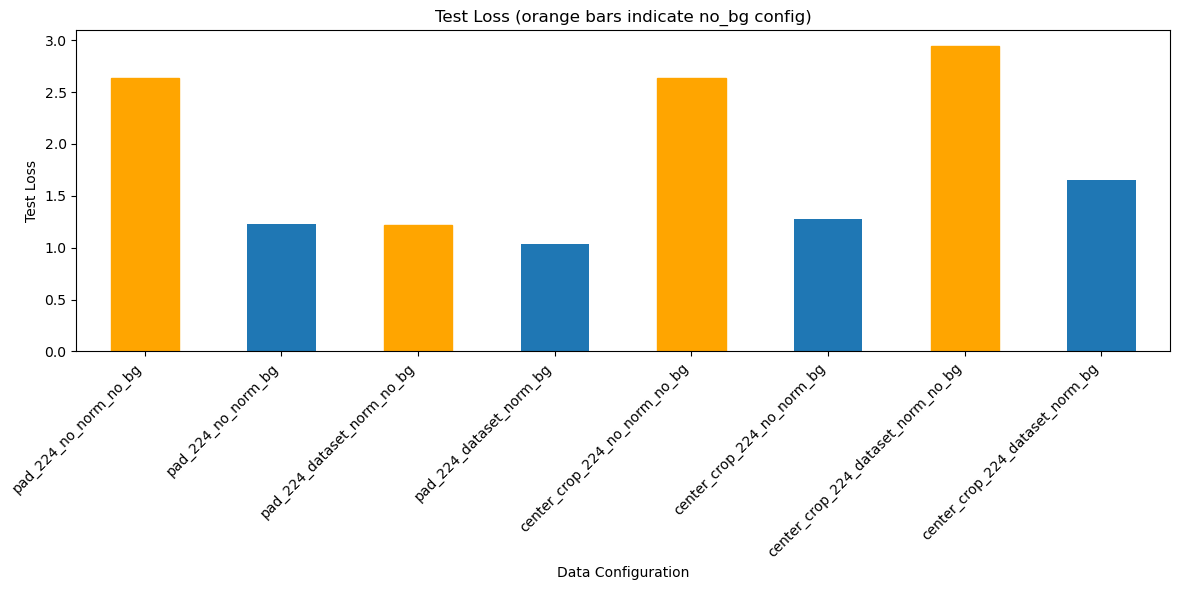

In [28]:
# Bar chart comparing the test loss for each fold
plot_metrics(results_df, "test_loss", "Test Loss")

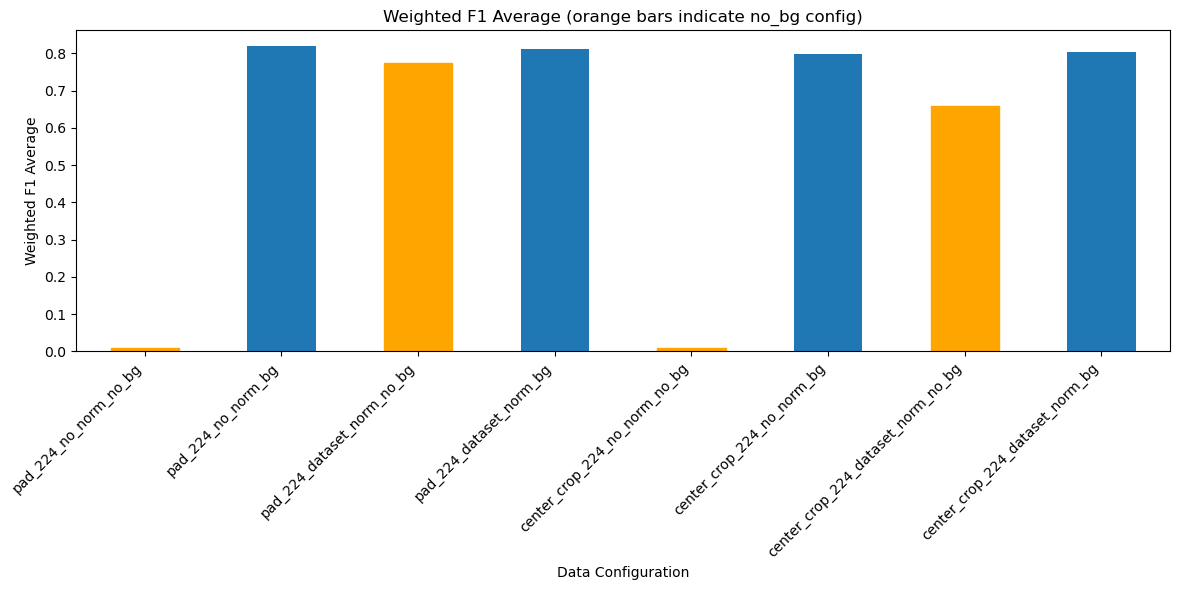

In [29]:
# Bar chart comparing the weighted F1 averages for each fold
plot_metrics(results_df, "weighted_f1_avg", "Weighted F1 Average")

#### Results
Applying no normalisation along with no background subtraction causes the model to collapse. 

Background subtraction provides better performance in every configuration, probably due to sensor noise being removed.

Normalisation has a minimal effect so will be set to None for now, but will be investigated further, later in the notebook. 

Padding consistently outperforms centre cropping. Padding is the preferable method as cropping means losing potentially valuable data from the image edges.

The chosen configuration moving forward is therefore *pad_224_no_norm_bg*:

**Resize method:** Pad and then resize tactile images to 224x224.

**Normalisation:** Do not normalise.

**Background subtraction:** Subtract the baseline.jpg image (DIGIT output when no contact with an object is made).

#### Updating Config File
Now we have our chosen set of parameters, we should save the dictionary for use in the next experiments.

In [31]:
# Get chosen data config dictionary
chosen_config_index = titles.index("pad_224_no_norm_bg")
chosen_data_config = data_configs[chosen_config_index]
chosen_data_config

{'random_state': 167,
 'split_size': 0.2,
 'stratify_label': 'object',
 'filtered_force_level': None,
 'filtered_motion': None,
 'transform_name': 'pad_224',
 'bg_path': '../data/baseline.jpg',
 'norm_type': None,
 'norm_cache_path': '../configs/norm_cache.json',
 'batch_size': 32,
 'num_workers': 0,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

## Testing Random Cropping
Now we know that padding outperforms centre cropping, we can try random cropping to see if that outperforms padding.

#### Load Data

In [ ]:
# Start with chosen config (pad to 224 with background subtraction and no normalisation)
data_config = chosen_data_config.copy()
# Update the transform name to random_crop_224
data_config["transform_name"] = "random_crop_224"

In [33]:
# Get the dataloaders
# We don't need the class-label lists again as we are using the same training set
dataloaders, _ = get_dataloaders(data_config)

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120


#### Training

In [36]:
# Use the same model training configuration but update the title
train_config["model_title"] = "random_crop_224_no_norm_bg"

In [37]:
# Initialise the model
model = BaselineCNNModel(num_classes=num_train_classes)
# Train the model and save the history
model, history = train_classifier(
    model=model,
    device=device,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    target_label="object",
    train_config=train_config,
)

Starting training of random_crop_224_no_norm_bg on device: cuda


Epoch 1/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 1/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 1/3 - Train Loss: 0.8912, Train Acc: 69.62%, Val Loss: 0.9870, Val Acc: 72.73%


Epoch 2/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 2/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 2/3 - Train Loss: 0.2488, Train Acc: 91.60%, Val Loss: 0.9905, Val Acc: 77.16%


Epoch 3/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 3/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 3/3 - Train Loss: 0.1619, Train Acc: 94.66%, Val Loss: 1.4065, Val Acc: 74.80%
Loaded best model checkpoint from epoch 2.


#### Evaluation

In [38]:
# Evaluate the model on the test set
results = eval_classifier(
    model=model,
    model_title=train_config["model_title"],
    device=device,
    test_loader=dataloaders["test"],
    target_label="object",
)

Starting test evaluation of random_crop_224_no_norm_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 0.9565, test Accuracy: 77.51%
test Weighted F1 Average: 0.7712


#### Results
pad_224_no_norm_bg results vs random_crop_224_no_norm_bg results: 

**Test accuracy:** 82.70% vs 77.51%

**Test loss:** 1.23 vs 0.96

**F1 score:** 0.82 vs 0.77

The padding version outperforms the random crop version in accuracy and F1 metrics. 
Therefore we will keep padding as the chosen transform.

## Testing ResNet Normalisation
When we tested tactile image normalisation earlier (using the std and mean of the training data), the results showed a negligible difference compared to not normalising. This was using a simple CNN baseline though - perhaps the effects of normalisation would be clearer using a pretrained backbone?

In this experiment, we will use a pretrained ResNet-18 backbone and test three different normalisation strategies:
1. No normalisation
2. Normalise images using the ImageNet std and mean values
3. Normalise images using the training data std and mean values

ImageNet normalisation is usually recommended when using pretrained models that were trained with ImageNet data, but as tactile images are so different from standard RGB images, it may be that dataset normalisation or no normalisation perform better.

#### Load Data

In [ ]:
# Create a list of data configs for each fold
# Start with chosen config (pad to 224 with background subtraction and no normalisation)
data_configs = [chosen_data_config.copy() for _ in range(3)]

In [ ]:
# Define the different norm types to test
changes = [
    {"norm_type": None},
    {"norm_type": "imagenet"},
    {"norm_type": "dataset"},
]

In [ ]:
# Define the titles for each data config
titles = ["resnet_no_norm_bg", "resnet_imagenet_norm_bg", "resnet_dataset_norm_bg"]

In [ ]:
# Update the data configs with the different norm types
for i in range(len(data_configs)):
    data_configs[i].update(changes[i])

In [12]:
# Get (dataloaders, label_lists) tuples for each fold using the different data configs
data = [get_dataloaders(cfg) for cfg in data_configs]

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Loading imagenet normalisation stats.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found, loading normalisation stats.


In [13]:
# Get the dataloaders
# We don't need the class-label lists again as we are using the same training set
dataloaders = [item[0] for item in data]

#### Training

In [14]:
# Create a list of training configs for each fold
train_configs = [train_config.copy() for _ in range(3)]

In [15]:
# Update the training configs with the different titles for each fold
for i in range(len(train_configs)):
    train_configs[i]["model_title"] = titles[i]

In [16]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = PretrainedModel(model_type="resnet18", num_classes=num_train_classes)
    # Train the model and save the history
    model, history = train_classifier(
        model=model,
        device=device,
        train_loader=dataloaders[i]["train"],
        val_loader=dataloaders[i]["val"],
        target_label="object",
        train_config=train_configs[i],
    )
    models.append(model)
    histories.append(history)
    print("-----")

Starting training of resnet_no_norm_bg on device: cuda


Epoch 1/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 1/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 1/3 - Train Loss: 0.2289, Train Acc: 92.29%, Val Loss: 0.4851, Val Acc: 89.89%


Epoch 2/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

...

Epoch 2/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 2/3 - Train Loss: 0.0553, Train Acc: 98.19%, Val Loss: 0.4596, Val Acc: 92.32%


Epoch 3/3 - Train:   0%|          | 0/3023 [00:00<?, ?it/s]

Epoch 3/3 - Val:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 3/3 - Train Loss: 0.0352, Train Acc: 98.92%, Val Loss: 0.2180, Val Acc: 96.09%
Loaded best model checkpoint from epoch 3.
-----


#### Evaluation

In [17]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    model = models[i]
    result = eval_classifier(
        model=model,
        model_title=train_configs[i]["model_title"],
        device=device,
        test_loader=dataloaders[i]["test"],
        target_label="object",
    )
    results.append(result)
    print("-----")

Starting test evaluation of resnet_no_norm_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 0.2189, test Accuracy: 94.27%
test Weighted F1 Average: 0.9423
-----
Starting test evaluation of resnet_imagenet_norm_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 0.4869, test Accuracy: 87.62%
test Weighted F1 Average: 0.8747
-----
Starting test evaluation of resnet_dataset_norm_bg on device: cuda


test:   0%|          | 0/379 [00:00<?, ?it/s]

test Loss: 0.1869, test Accuracy: 95.87%
test Weighted F1 Average: 0.9587
-----


#### Results
The ImageNet normalisation performed the worst, confirming that it is not best suited for tactile images.

Much like the previous experiments, there was only a small difference between dataset normalisation and no normalisation.

However, as normalisation is considered general good practice, we will use dataset normalisation as the default method going forward.